# Supermarket Sales - End-to-End Data Analysis

This notebook performs:
- Data loading
- Cleaning
- EDA
- Statistical hypothesis testing
- Simple regression model

Dataset used: supermarket_sales.csv


In [1]:

import pandas as pd

df = pd.read_csv('supermarket_sales.csv')
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [2]:

# Clean column names and ensure numeric types
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

numeric_cols = ['unit_price', 'quantity', 'tax_5%', 'total', 'rating']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   invoice_id               1000 non-null   object 
 1   branch                   1000 non-null   object 
 2   city                     1000 non-null   object 
 3   customer_type            1000 non-null   object 
 4   gender                   1000 non-null   object 
 5   product_line             1000 non-null   object 
 6   unit_price               1000 non-null   float64
 7   quantity                 1000 non-null   int64  
 8   tax_5%                   1000 non-null   float64
 9   total                    1000 non-null   float64
 10  date                     1000 non-null   object 
 11  time                     1000 non-null   object 
 12  payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross_margin_percentage  

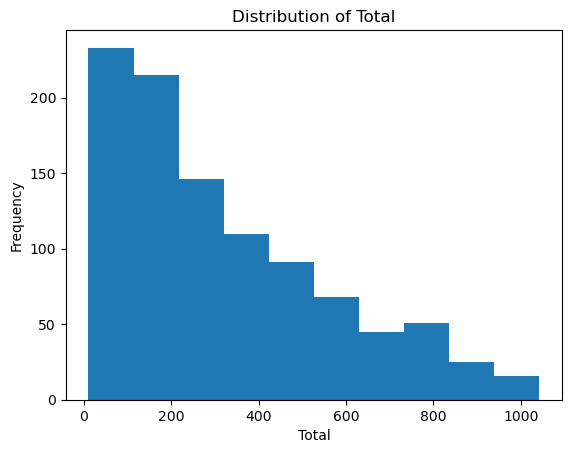

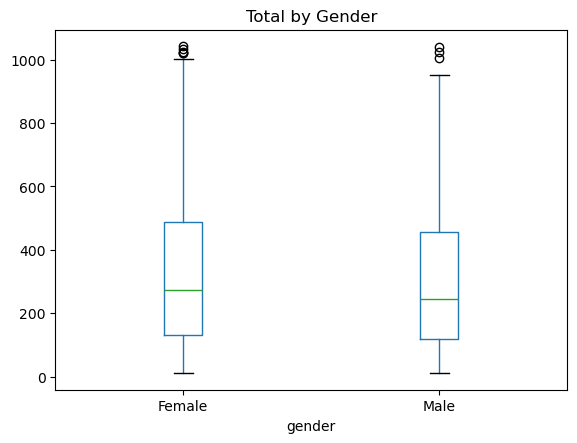

In [3]:

import matplotlib.pyplot as plt

# Histogram of Total
plt.hist(df['total'])
plt.title("Distribution of Total")
plt.xlabel("Total")
plt.ylabel("Frequency")
plt.show()

# Boxplot of Total by Gender
df.boxplot(column='total', by='gender', grid=False)
plt.title("Total by Gender")
plt.suptitle("")
plt.show()


In [4]:

import scipy.stats as stats

# T-test: Total by Gender
male = df[df['gender']=='Male']['total']
female = df[df['gender']=='Female']['total']

ttest_res = stats.ttest_ind(male, female, equal_var=False, nan_policy='omit')
ttest_res


TtestResult(statistic=np.float64(-1.5642197047338087), pvalue=np.float64(0.11808320560465774), df=np.float64(997.3404314560546))

In [5]:

# ANOVA: Total by Product Line
groups = [g['total'].dropna() for name, g in df.groupby('product_line')]
anova_res = stats.f_oneway(*groups)
anova_res


F_onewayResult(statistic=np.float64(0.3379647544618803), pvalue=np.float64(0.8900398045912835))

In [6]:

# Chi-square: Payment vs Customer type
cont_table = pd.crosstab(df['payment'], df['customer_type'])
chi2, p, dof, exp = stats.chi2_contingency(cont_table)
chi2, p, dof


(np.float64(5.217008430036758), np.float64(0.0736446179323698), 2)

In [7]:

# Pearson Correlation: Total vs Rating
stats.pearsonr(df['total'], df['rating'])


PearsonRResult(statistic=np.float64(-0.03644170499701835), pvalue=np.float64(0.2495969097543973))

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['unit_price', 'quantity', 'rating']]
y = df['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

(mean_squared_error(y_test, pred), r2_score(y_test, pred))


(6199.308620580809, 0.9047125222256868)